In [1]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline

# 训练数据（文本 + 标签）
X_train = ["Win money now", "Limited offer", "Call your mom", "Meeting at office"]
y_train = ["spam", "spam", "ham", "ham"]  # spam = 垃圾邮件, ham = 正常邮件

# 测试数据
X_test = ["Win a free phone", "Office meeting"]

# 朴素贝叶斯分类器
model = make_pipeline(CountVectorizer(), MultinomialNB())
model.fit(X_train, y_train)  # 训练模型

# 预测
predictions = model.predict(X_test)
print(predictions)  # 预测结果


['spam' 'ham']


**可视化：朴素贝叶斯关键词重要性**

通过比较每个词在垃圾邮件和正常邮件中的对数概率差异，找出最具区分度的关键词。

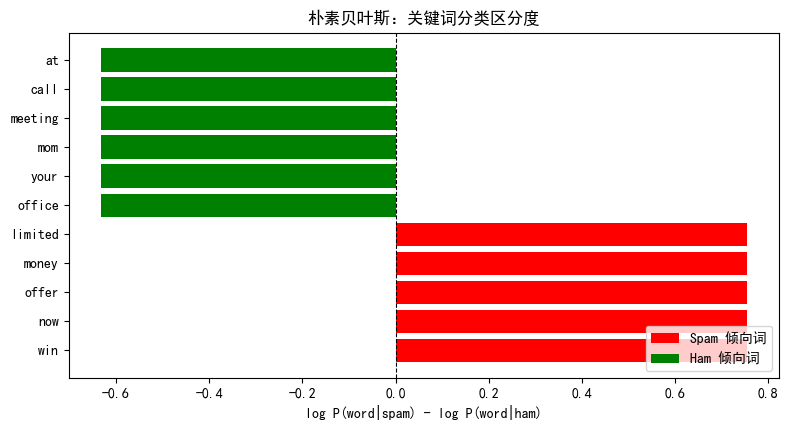

In [2]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
from matplotlib.patches import Patch

# 获取词汇表与对数概率
vectorizer = model.named_steps['countvectorizer']
nb = model.named_steps['multinomialnb']
feature_names = vectorizer.get_feature_names_out()

# sklearn classes_ 按字母序排列: ham 在前, spam 在后
log_prob_ham = nb.feature_log_prob_[list(model.classes_).index('ham')]
log_prob_spam = nb.feature_log_prob_[list(model.classes_).index('spam')]

# 对数概率差异: 正值 = spam 倾向词, 负值 = ham 倾向词
diff = log_prob_spam - log_prob_ham

# 按差异值排序：从最偏向 ham 到最偏向 spam
order = np.argsort(diff)
sorted_words = [feature_names[i] for i in order]
sorted_values = [diff[i] for i in order]
colors = ['green' if v < 0 else 'red' for v in sorted_values]

fig, ax = plt.subplots(figsize=(8, max(4, len(sorted_words) * 0.4)))
ax.barh(np.arange(len(sorted_words)), sorted_values, color=colors)
ax.set_yticks(np.arange(len(sorted_words)))
ax.set_yticklabels(sorted_words)
ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('log P(word|spam) - log P(word|ham)')
ax.set_title('朴素贝叶斯：关键词分类区分度')
ax.invert_yaxis()

legend_elements = [
    Patch(facecolor='red', label='Spam 倾向词'),
    Patch(facecolor='green', label='Ham 倾向词')
]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()


**可视化：测试样本预测概率**

展示模型对每个测试样本属于 spam / ham 两类的预测概率。

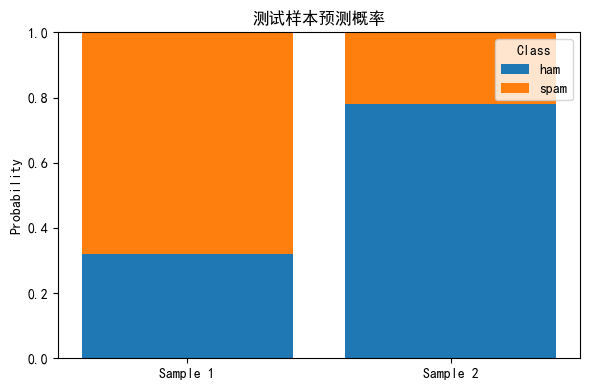

In [3]:
import matplotlib.pyplot as plt

probs = model.predict_proba(X_test)
classes = model.classes_

fig, ax = plt.subplots(figsize=(6, 4))
bottom = np.zeros(len(X_test))
for i, cls in enumerate(classes):
    ax.bar(range(len(X_test)), probs[:, i], bottom=bottom, label=cls)
    bottom += probs[:, i]

ax.set_xticks(range(len(X_test)))
ax.set_xticklabels([f'Sample {i+1}' for i in range(len(X_test))])
ax.set_ylabel('Probability')
ax.set_title('测试样本预测概率')
ax.legend(title='Class')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()
